# Slide 4

KMeans is the most common starting point for clustering. Its objective is to find a partition that minimizes the within-cluster sum of squares (Inertia), an objective achieved via an iterative process known as Lloyd’s Algorithm.

## The Iterative Process (Lloyd’s Algorithm):

1. **Initialize:** Randomly place k centroids.
2. **Assign:** Assign each data point to its closest centroid.
3. **Update:** Recalculate each centroid as the mean of the points assigned to it.
4. **Repeat:** Iterate steps 2–3 until centroids no longer move.

The major factors that can impact the performance of the K-means algorithm are the following:
1. Choosing the initial centroids.
2. Estimating the number of clusters K.
3. The distance metric used (e.g., Euclidean vs. Manhattan).

✓ Converged at iteration 20
✓ GIF saved to: kmeans_animation.gif
✓ Total frames: 24
✓ GIF saved to: kmeans_animation.gif
✓ Total frames: 24


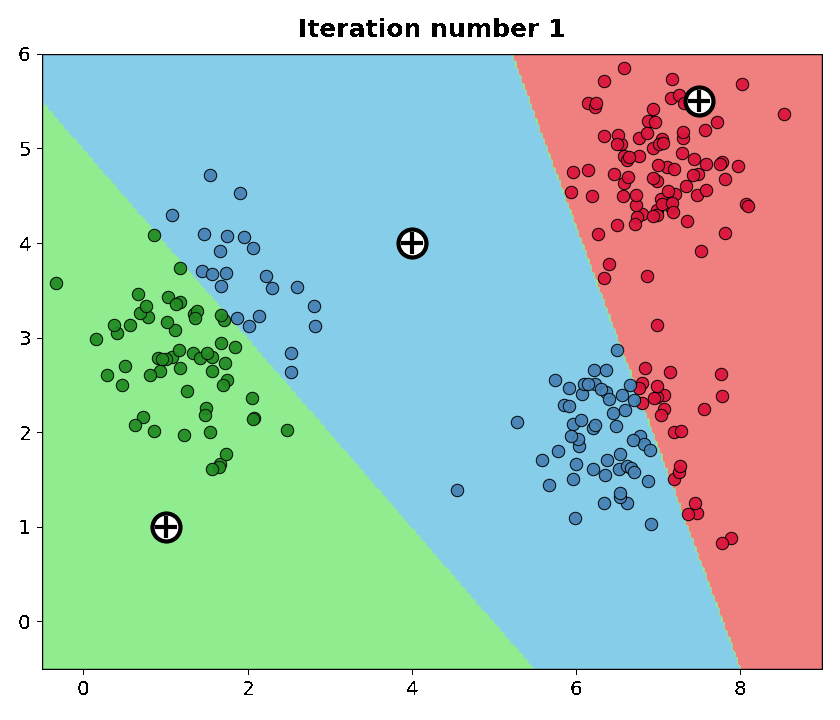

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

# Set random seed for reproducibility
np.random.seed(42)

# Generate well-separated cluster data
n_points = 80

# Red cluster - left side, spread vertically
cluster1 = np.random.randn(n_points, 2) * 0.7 + [1.5, 3.0]

# Green cluster - bottom right
cluster2 = np.random.randn(n_points, 2) * 0.6 + [6.5, 2.0]

# Cyan/Blue cluster - top right
cluster3 = np.random.randn(n_points, 2) * 0.5 + [7.0, 4.8]

X = np.vstack([cluster1, cluster2, cluster3])

# K-means parameters
k = 3
max_iterations = 20

# Initialize centroids VERY far from true centers to show slow convergence
centroids = np.array([
    [7.5, 5.5],   # Start in cyan area - will slowly migrate to red
    [1.0, 1.0],   # Start in corner - will move to green
    [4.0, 4.0],   # Start in middle - will move to cyan
])

# Colors matching the reference image
colors = ['#F08080', '#90EE90', '#87CEEB']  # Light coral, Light green, Sky blue
point_colors = ['#DC143C', '#228B22', '#4682B4']  # Crimson, Forest green, Steel blue

def assign_clusters(X, centroids):
    """Assign each point to nearest centroid"""
    distances = np.sqrt(((X[:, np.newaxis] - centroids) ** 2).sum(axis=2))
    return np.argmin(distances, axis=1)

def create_decision_boundary(centroids, ax, colors):
    """Create Voronoi-like decision boundaries"""
    x_min, x_max = -0.5, 9
    y_min, y_max = -0.5, 6
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_labels = assign_clusters(grid_points, centroids)
    grid_labels = grid_labels.reshape(xx.shape)
    
    ax.contourf(xx, yy, grid_labels, levels=[-0.5, 0.5, 1.5, 2.5], 
                colors=colors, alpha=0.75)

def create_frame(X, centroids, labels, iteration, colors, point_colors):
    """Create a single frame of the animation"""
    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    
    # Draw decision boundaries
    create_decision_boundary(centroids, ax, colors)
    
    # Plot points with cluster colors
    for i in range(k):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], 
                   c=point_colors[i], 
                   edgecolors='black', 
                   linewidths=0.6, 
                   s=55, 
                   alpha=0.9,
                   zorder=2)
    
    # Plot centroids - white circle with black cross (⊕ symbol)
    for centroid in centroids:
        ax.scatter(centroid[0], centroid[1], 
                   c='white', 
                   marker='o', 
                   s=280, 
                   edgecolors='black', 
                   linewidths=2.5,
                   zorder=3)
        ax.scatter(centroid[0], centroid[1], 
                   c='black', 
                   marker='+', 
                   s=180, 
                   linewidths=2.5,
                   zorder=4)
    
    # ax.set_xlabel('X1', fontsize=14, fontweight='bold')
    # ax.set_ylabel('X2', fontsize=14, fontweight='bold')
    ax.set_title(f'Iteration number {iteration}', fontsize=15, fontweight='bold', pad=10)
    
    ax.set_xlim(-0.5, 9)
    ax.set_ylim(-0.5, 6)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    
    # Convert to PIL Image with transparency
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, transparent=True)
    buf.seek(0)
    img = Image.open(buf).convert('RGBA')
    plt.close(fig)
    buf.close()
    
    return img

# Use slower update rate (momentum) to show more iterations
momentum = 0.4

# Run K-means and collect frames
frames = []

for iteration in range(1, max_iterations + 1):
    labels = assign_clusters(X, centroids)
    frame = create_frame(X, centroids, labels, iteration, colors, point_colors)
    frames.append(frame)
    
    target_centroids = np.array([X[labels == i].mean(axis=0) if np.sum(labels == i) > 0 
                                  else centroids[i] for i in range(k)])
    
    new_centroids = centroids + momentum * (target_centroids - centroids)
    
    if np.allclose(centroids, new_centroids, atol=1e-4):
        print(f"✓ Converged at iteration {iteration}")
        for _ in range(4):
            frames.append(frame)
        break
    
    centroids = new_centroids

# Convert RGBA frames to palette mode with transparency for GIF
def convert_to_gif_frame(img):
    """Convert RGBA image to palette mode with transparency"""
    # Create a copy and convert
    alpha = img.split()[3]
    # Convert to palette mode
    img_p = img.convert('P', palette=Image.ADAPTIVE, colors=255)
    # Set transparency
    mask = Image.eval(alpha, lambda a: 255 if a <= 128 else 0)
    img_p.paste(255, mask)
    return img_p

gif_frames = [convert_to_gif_frame(f) for f in frames]

# Save as GIF with proper disposal
output_path = 'kmeans_animation.gif'
gif_frames[0].save(
    output_path,
    save_all=True,
    append_images=gif_frames[1:],
    duration=600,
    loop=0,
    transparency=255,
    disposal=2  # Clear frame before drawing next (prevents ghosting)
)

print(f"✓ GIF saved to: {output_path}")
print(f"✓ Total frames: {len(frames)}")

# Display the animation
from IPython.display import Image as IPImage, display
display(IPImage(filename=output_path))

# Slide 5

## K-Means Failure Modes
1. **Non-optimal Number of Clusters**
No "true" number of clusters exists. Choose k based on data-driven criteria and domain knowledge.

2. **Anisotropically Distributed Blobs**
K-means minimizes Euclidean distance to centroids, assuming spherical (isotropic) clusters. Elongated clusters violate this assumption.

3. **Unequal Variance**
K-means assumes clusters have equal variance. Large-spread clusters get incorrectly split.

4. **Unevenly Sized Blobs**
K-means doesn't require equal cluster sizes, but large clusters can dominate, pulling centroids away from smaller clusters.

Generating: Non-optimal Number of Clusters...
Generating: Anisotropically Distributed Blobs...
Generating: Anisotropically Distributed Blobs...
Generating: Unequal Variance...
Generating: Unequal Variance...
Generating: Unevenly Sized Blobs...
Generating: Unevenly Sized Blobs...
✓ Saved: kmeans_failure_0.gif
✓ Saved: kmeans_failure_1.gif
✓ Saved: kmeans_failure_0.gif
✓ Saved: kmeans_failure_1.gif
✓ Saved: kmeans_failure_2.gif
✓ Saved: kmeans_failure_3.gif

Creating combined 2x2 grid animation...
✓ Saved: kmeans_failure_2.gif
✓ Saved: kmeans_failure_3.gif

Creating combined 2x2 grid animation...
✓ Saved: kmeans_failure_modes_combined.gif
✓ Saved: kmeans_failure_modes_combined.gif


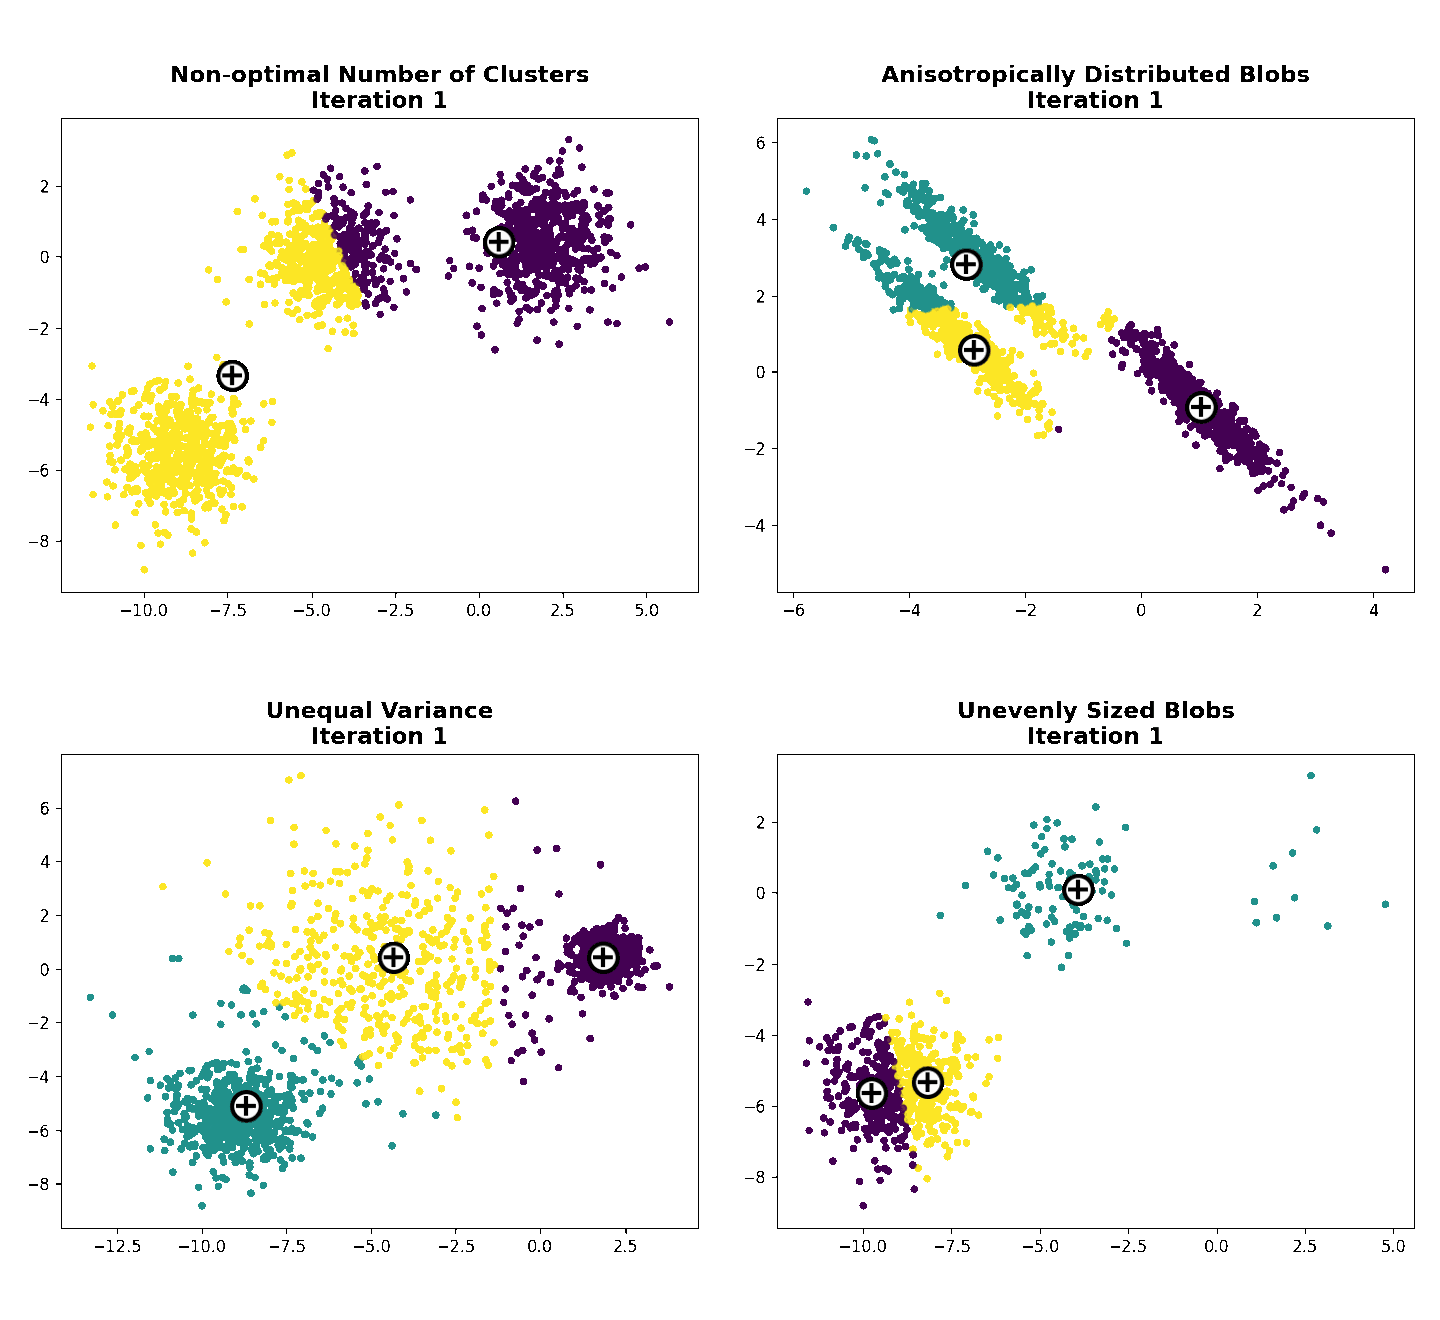

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# =============================================================================
# DATA GENERATION - Exact copy from scikit-learn example
# =============================================================================
n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs

common_params = {
    "n_init": "auto",
    "random_state": random_state,
}

# =============================================================================
# Define the 4 failure mode scenarios - exactly like sklearn example
# =============================================================================
scenarios = [
    {"data": X, "n_clusters": 2, "title": "Non-optimal Number of Clusters"},
    {"data": X_aniso, "n_clusters": 3, "title": "Anisotropically Distributed Blobs"},
    {"data": X_varied, "n_clusters": 3, "title": "Unequal Variance"},
    {"data": X_filtered, "n_clusters": 3, "title": "Unevenly Sized Blobs"},
]

def create_frame(X, y_pred, centers, title, iteration, n_clusters):
    """Create a single frame matching sklearn example style with visible centroids"""
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    
    # Plot data points
    ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=15, alpha=0.8)
    
    # Plot centroids - large white circle with black cross
    for center in centers:
        ax.scatter(center[0], center[1], 
                   c='white', marker='o', s=300, 
                   edgecolors='black', linewidths=2.5, zorder=10)
        ax.scatter(center[0], center[1], 
                   c='black', marker='+', s=150, 
                   linewidths=2.5, zorder=11)
    
    ax.set_title(f"{title}\nIteration {iteration}", fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    
    plt.tight_layout()
    
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, transparent=True)
    buf.seek(0)
    img = Image.open(buf).convert('RGBA')
    plt.close(fig)
    buf.close()
    
    return img

def run_kmeans_with_frames(X, n_clusters, title, max_iter=15):
    """Run KMeans step by step using sklearn, capturing each iteration"""
    frames = []
    
    # Initialize KMeans with max_iter=1 to step through manually
    kmeans = KMeans(n_clusters=n_clusters, n_init=1, max_iter=1, 
                    random_state=random_state, init='k-means++')
    
    # First fit to get initial state
    kmeans.fit(X)
    y_pred = kmeans.labels_
    centers = kmeans.cluster_centers_.copy()
    
    frame = create_frame(X, y_pred, centers, title, 1, n_clusters)
    frames.append(frame)
    
    # Continue iterations
    for iteration in range(2, max_iter + 1):
        # Create new KMeans initialized with current centers
        kmeans = KMeans(n_clusters=n_clusters, n_init=1, max_iter=1,
                        random_state=random_state, init=centers)
        kmeans.fit(X)
        
        new_centers = kmeans.cluster_centers_
        y_pred = kmeans.labels_
        
        frame = create_frame(X, y_pred, new_centers, title, iteration, n_clusters)
        frames.append(frame)
        
        # Check convergence
        if np.allclose(centers, new_centers, atol=1e-4):
            # Add extra frames to pause at end
            for _ in range(3):
                frames.append(frame)
            break
            
        centers = new_centers.copy()
    
    return frames

def convert_to_gif_frame(img):
    """Convert RGBA to palette mode with transparency"""
    alpha = img.split()[3]
    img_p = img.convert('P', palette=Image.ADAPTIVE, colors=255)
    mask = Image.eval(alpha, lambda a: 255 if a <= 128 else 0)
    img_p.paste(255, mask)
    return img_p

# =============================================================================
# Generate animations for all 4 failure modes
# =============================================================================
all_animations = {}

for i, scenario in enumerate(scenarios):
    print(f"Generating: {scenario['title']}...")
    frames = run_kmeans_with_frames(
        scenario['data'], 
        scenario['n_clusters'], 
        scenario['title']
    )
    all_animations[i] = frames

# Save individual GIFs
for i, scenario in enumerate(scenarios):
    gif_frames = [convert_to_gif_frame(f) for f in all_animations[i]]
    output_path = f'kmeans_failure_{i}.gif'
    gif_frames[0].save(
        output_path,
        save_all=True,
        append_images=gif_frames[1:],
        duration=500,
        loop=0,
        transparency=255,
        disposal=2
    )
    print(f"✓ Saved: {output_path}")

# =============================================================================
# Create combined 2x2 grid animation
# =============================================================================
print("\nCreating combined 2x2 grid animation...")

# Find max frames and pad shorter ones
max_frames = max(len(f) for f in all_animations.values())
for i in all_animations:
    while len(all_animations[i]) < max_frames:
        all_animations[i].append(all_animations[i][-1])

# Create combined frames
combined_frames = []
for frame_idx in range(max_frames):
    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    fig.patch.set_alpha(0)
    
    for i, ax in enumerate(axes.flat):
        frame_img = all_animations[i][frame_idx]
        ax.imshow(frame_img)
        ax.axis('off')
    
    plt.tight_layout(pad=0.5)
    
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, transparent=True)
    buf.seek(0)
    img = Image.open(buf).convert('RGBA')
    plt.close(fig)
    buf.close()
    
    combined_frames.append(img)

# Save combined GIF
gif_combined = [convert_to_gif_frame(f) for f in combined_frames]
gif_combined[0].save(
    'kmeans_failure_modes_combined.gif',
    save_all=True,
    append_images=gif_combined[1:],
    duration=600,
    loop=0,
    transparency=255,
    disposal=2
)
print("✓ Saved: kmeans_failure_modes_combined.gif")

# Display
from IPython.display import Image as IPImage, display
display(IPImage(filename='kmeans_failure_modes_combined.gif'))

# Slide 6

## Possible Solutions

1. **Optimal Number of Clusters**
Use data-driven methods (elbow plot, silhouette score) and domain expertise to determine k. Here, k=3 correctly identifies the natural groupings.

2. **Anisotropically Distributed Blobs (Gaussian Mixture)**
GMM models each cluster as an ellipse with its own covariance matrix, naturally capturing elongated and rotated cluster shapes.

3. **Unequal Variance (Gaussian Mixture)**
GMM allows each cluster to have different spreads. High-variance clusters stay intact instead of being split.

4. **Unevenly Sized Blobs (n_init=10)**
Multiple random initializations (n_init=10) increase the chance of finding centroids that correctly identify all clusters, including small ones.

Generating: Optimal Number of Clusters...
Generating: Anisotropically Distributed Blobs...
Generating: Anisotropically Distributed Blobs...


C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or

Generating: Unequal Variance...


C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(
C:\Users\e176097\AppData\Roaming\Python\Python312\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or

Generating: Unevenly Sized Blobs...
✓ Saved: kmeans_solution_0.gif
✓ Saved: kmeans_solution_1.gif
✓ Saved: kmeans_solution_0.gif
✓ Saved: kmeans_solution_1.gif
✓ Saved: kmeans_solution_2.gif
✓ Saved: kmeans_solution_3.gif

Creating combined 2x2 solutions grid animation...
✓ Saved: kmeans_solution_2.gif
✓ Saved: kmeans_solution_3.gif

Creating combined 2x2 solutions grid animation...
✓ Saved: kmeans_solutions_combined.gif
✓ Saved: kmeans_solutions_combined.gif


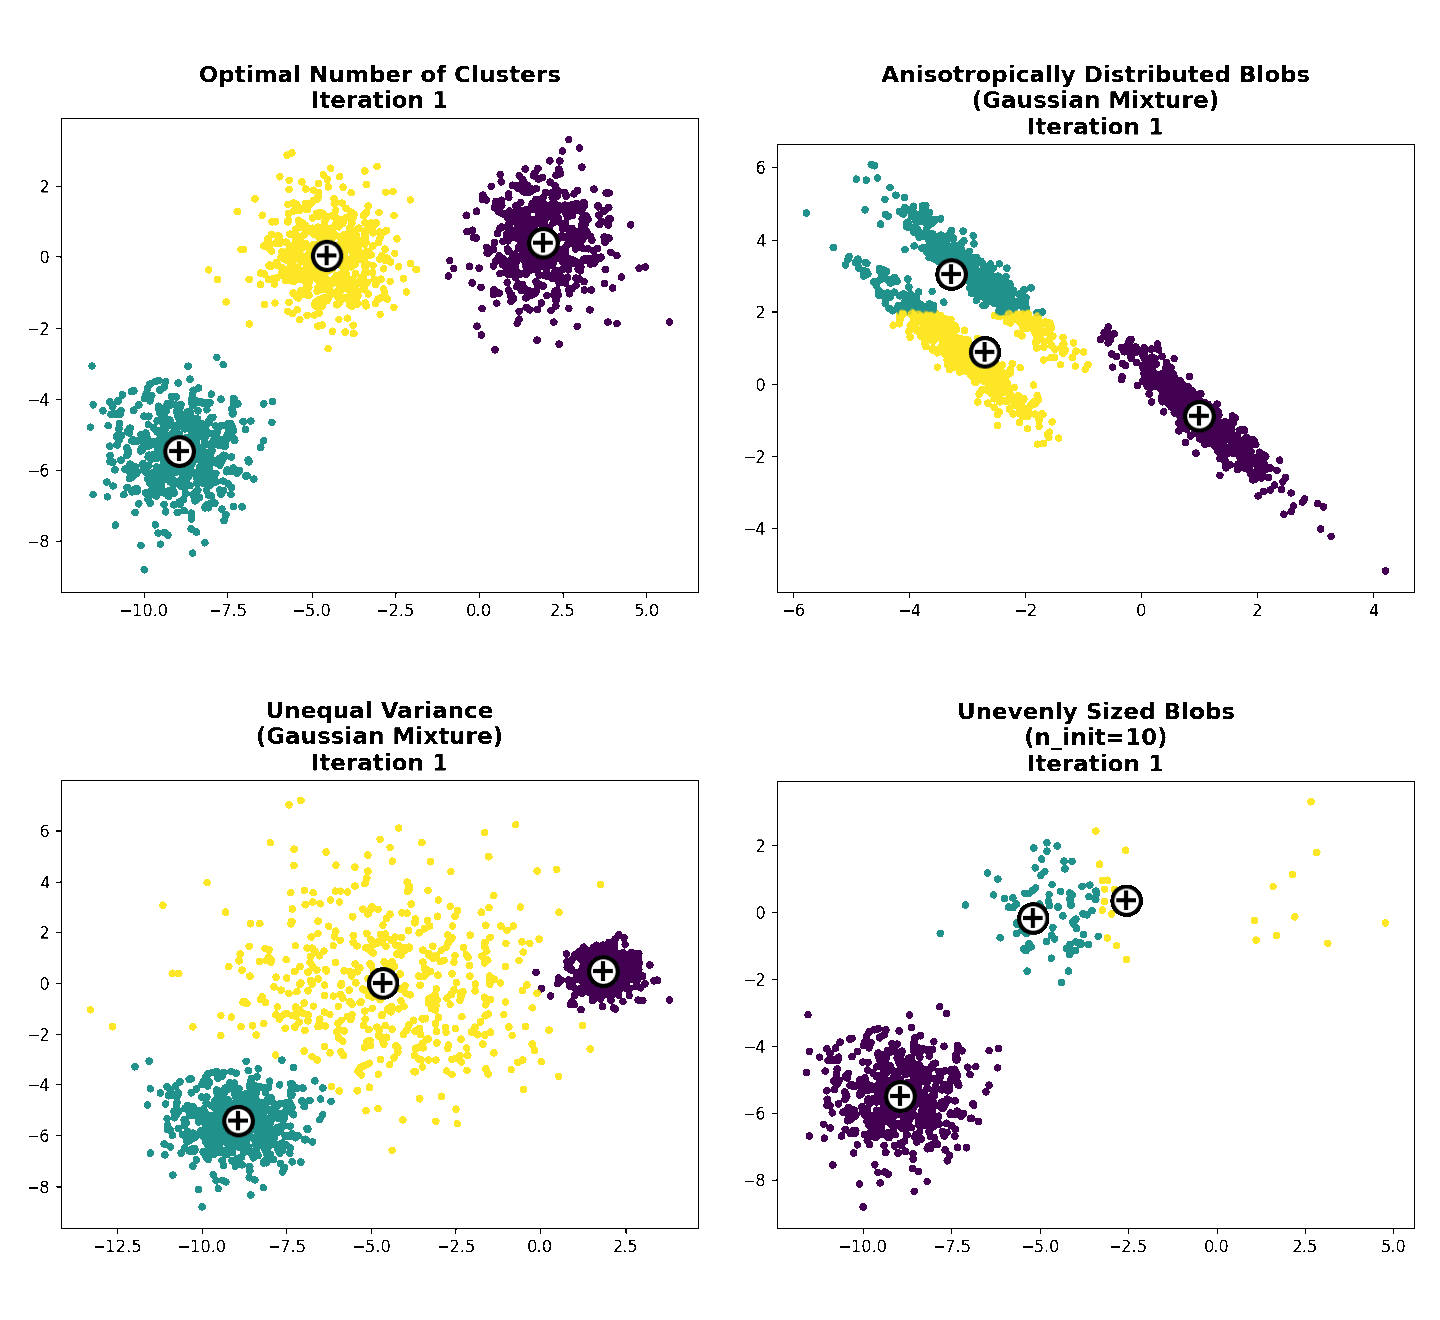

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# =============================================================================
# DATA GENERATION - Exact copy from scikit-learn example
# =============================================================================
n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs

# =============================================================================
# SOLUTIONS - Same order as failure modes (matching sklearn notebook)
# Position 0: Non-optimal k -> Solution: Use k=3
# Position 1: Anisotropic -> Solution: Use GaussianMixture
# Position 2: Unequal Variance -> Solution: Use GaussianMixture  
# Position 3: Unevenly Sized -> Solution: Use n_init=10
# =============================================================================
solutions = [
    {
        "data": X, 
        "model": "kmeans",
        "n_clusters": 3, 
        "title": "Optimal Number of Clusters"
    },
    {
        "data": X_aniso, 
        "model": "gmm",
        "n_clusters": 3, 
        "title": "Anisotropically Distributed Blobs\n(Gaussian Mixture)"
    },
    {
        "data": X_varied, 
        "model": "gmm",
        "n_clusters": 3, 
        "title": "Unequal Variance\n(Gaussian Mixture)"
    },
    {
        "data": X_filtered, 
        "model": "kmeans",
        "n_clusters": 3, 
        "n_init": 10,
        "title": "Unevenly Sized Blobs\n(n_init=10)"
    },
]

def create_solution_frame(X, y_pred, centers, title, iteration, n_clusters, show_centroids=True):
    """Create a single frame for solution animation"""
    fig, ax = plt.subplots(figsize=(6, 5))
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)
    
    # Plot data points
    ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=15, alpha=0.8)
    
    # Plot centroids/means
    if show_centroids and centers is not None:
        for center in centers:
            ax.scatter(center[0], center[1], 
                       c='white', marker='o', s=300, 
                       edgecolors='black', linewidths=2.5, zorder=10)
            ax.scatter(center[0], center[1], 
                       c='black', marker='+', s=150, 
                       linewidths=2.5, zorder=11)
    
    ax.set_title(f"{title}\nIteration {iteration}", fontsize=14, fontweight='bold')
    ax.tick_params(axis='both', labelsize=10)
    
    plt.tight_layout()
    
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, transparent=True)
    buf.seek(0)
    img = Image.open(buf).convert('RGBA')
    plt.close(fig)
    buf.close()
    
    return img

def run_kmeans_solution(X, n_clusters, title, n_init=1, max_iter=15):
    """Run KMeans step by step for solution scenarios"""
    frames = []
    
    if n_init > 1:
        # For n_init > 1: Find the best initialization and animate from there
        # Run n_init different initializations and find the best one
        best_inertia = float('inf')
        best_init_centers = None
        
        for seed in range(n_init):
            kmeans_init = KMeans(n_clusters=n_clusters, n_init=1, max_iter=1, 
                                 random_state=random_state + seed, init='k-means++')
            kmeans_init.fit(X)
            
            # Run full convergence to get final inertia
            kmeans_full = KMeans(n_clusters=n_clusters, n_init=1, 
                                 random_state=random_state + seed, init=kmeans_init.cluster_centers_)
            kmeans_full.fit(X)
            
            if kmeans_full.inertia_ < best_inertia:
                best_inertia = kmeans_full.inertia_
                best_init_centers = kmeans_init.cluster_centers_.copy()
        
        # Start animation from the best initialization
        centers = best_init_centers
    else:
        # Standard single init
        kmeans = KMeans(n_clusters=n_clusters, n_init=1, max_iter=1, 
                        random_state=random_state, init='k-means++')
        kmeans.fit(X)
        centers = kmeans.cluster_centers_.copy()
    
    # Create first frame
    y_pred = KMeans(n_clusters=n_clusters, n_init=1, max_iter=1, 
                    random_state=random_state, init=centers).fit(X).labels_
    frame = create_solution_frame(X, y_pred, centers, title, 1, n_clusters)
    frames.append(frame)
    
    # Continue iterations from the chosen initialization
    for iteration in range(2, max_iter + 1):
        kmeans = KMeans(n_clusters=n_clusters, n_init=1, max_iter=1,
                        random_state=random_state, init=centers)
        kmeans.fit(X)
        
        new_centers = kmeans.cluster_centers_
        y_pred = kmeans.labels_
        
        frame = create_solution_frame(X, y_pred, new_centers, title, iteration, n_clusters)
        frames.append(frame)
        
        if np.allclose(centers, new_centers, atol=1e-4):
            for _ in range(3):
                frames.append(frame)
            break
            
        centers = new_centers.copy()
    
    return frames

def run_gmm_solution(X, n_components, title, max_iter=15):
    """Run GMM step by step"""
    frames = []
    
    # GMM iterations to visualize
    iterations_to_show = [1, 2, 3, 5, 8, 12, 20, 50, 100]
    
    for i, n_iter in enumerate(iterations_to_show):
        gmm = GaussianMixture(n_components=n_components, max_iter=n_iter, 
                              random_state=random_state, n_init=1)
        gmm.fit(X)
        y_pred = gmm.predict(X)
        means = gmm.means_
        
        frame = create_solution_frame(X, y_pred, means, title, i + 1, n_components)
        frames.append(frame)
    
    # Add extra frames at end
    for _ in range(3):
        frames.append(frame)
    
    return frames

def convert_to_gif_frame(img):
    """Convert RGBA to palette mode with transparency"""
    alpha = img.split()[3]
    img_p = img.convert('P', palette=Image.ADAPTIVE, colors=255)
    mask = Image.eval(alpha, lambda a: 255 if a <= 128 else 0)
    img_p.paste(255, mask)
    return img_p

# =============================================================================
# Generate animations for all 4 solutions
# =============================================================================
solution_animations = {}

for i, sol in enumerate(solutions):
    print(f"Generating: {sol['title'].split(chr(10))[0]}...")
    
    if sol['model'] == 'kmeans':
        frames = run_kmeans_solution(
            sol['data'], 
            sol['n_clusters'], 
            sol['title'],
            sol.get('n_init', 1)
        )
    else:  # GMM
        frames = run_gmm_solution(
            sol['data'], 
            sol['n_clusters'], 
            sol['title']
        )
    
    solution_animations[i] = frames

# Save individual GIFs
for i, sol in enumerate(solutions):
    gif_frames = [convert_to_gif_frame(f) for f in solution_animations[i]]
    output_path = f'kmeans_solution_{i}.gif'
    gif_frames[0].save(
        output_path,
        save_all=True,
        append_images=gif_frames[1:],
        duration=500,
        loop=0,
        transparency=255,
        disposal=2
    )
    print(f"✓ Saved: {output_path}")

# =============================================================================
# Create combined 2x2 grid animation (same order as failure modes)
# =============================================================================
print("\nCreating combined 2x2 solutions grid animation...")

# Find max frames and pad
max_frames = max(len(f) for f in solution_animations.values())
for i in solution_animations:
    while len(solution_animations[i]) < max_frames:
        solution_animations[i].append(solution_animations[i][-1])

# Create combined frames
combined_solution_frames = []
for frame_idx in range(max_frames):
    fig, axes = plt.subplots(2, 2, figsize=(12, 11))
    fig.patch.set_alpha(0)
    
    for i, ax in enumerate(axes.flat):
        frame_img = solution_animations[i][frame_idx]
        ax.imshow(frame_img)
        ax.axis('off')
    
    plt.tight_layout(pad=0.5)
    
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=120, transparent=True)
    buf.seek(0)
    img = Image.open(buf).convert('RGBA')
    plt.close(fig)
    buf.close()
    
    combined_solution_frames.append(img)

# Save combined GIF
gif_combined = [convert_to_gif_frame(f) for f in combined_solution_frames]
gif_combined[0].save(
    'kmeans_solutions_combined.gif',
    save_all=True,
    append_images=gif_combined[1:],
    duration=600,
    loop=0,
    transparency=255,
    disposal=2
)
print("✓ Saved: kmeans_solutions_combined.gif")

# Display
from IPython.display import Image as IPImage, display
display(IPImage(filename='kmeans_solutions_combined.gif'))